In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df=pd.read_csv('D:\Python Notebooks\Salary Data.csv')


<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\People Links Laptop\AppData\Local\Temp\ipykernel_11144\2862907707.py:7: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv('D:\Python Notebooks\Salary Data.csv')


In [3]:
#Section 1: Data Understanding 
print("No of rows and cols",df.shape )#How many rows and columns are present in the dataset?
print('-'*50)
print("Null values ",df.isnull().sum()) #Which columns have missing values, and how many missing values are there in each
print('-'*50)
num_col=df.select_dtypes(include=['int64','float64']).sum() #identify numerical colomns
cat_col=df.select_dtypes(include=['int64','float64']).sum() #identify category colomns
print("NUmerical Colomns: ",num_col)
print("Category Colomns: ",cat_col)
print('-'*50)
mean=df['Age'].mean() #calculating mean
print('Mean: ',mean)
med=df['Age'].median() #calculating median
print('Median :',med)
std=df['Age'].std() #calculating stadard deviation
print('Standard Deviation',std)
print('-'*50)
print(df['Gender'].value_counts(normalize=100).idxmax(), "More") #Which gender has a higher proportion in the dataset
print("Printing percentages :",df['Gender'].value_counts(normalize=100)*100) #Percentage of both genders
print('-'*50)
print("Degrees ",df['Education Level'].unique()) #unique education levels and their proportion in the dataset.
print("Percentage",df['Education Level'].value_counts(normalize=100)*100)


No of rows and cols (375, 6)
--------------------------------------------------
Null values  Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
--------------------------------------------------
NUmerical Colomns:  Age                       13962.0
Years of Experience        3741.5
Salary                 37515350.0
dtype: float64
Category Colomns:  Age                       13962.0
Years of Experience        3741.5
Salary                 37515350.0
dtype: float64
--------------------------------------------------
Mean:  37.43163538873995
Median : 36.0
Standard Deviation 7.069072938567494
--------------------------------------------------
Male More
Printing percentages : Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64
--------------------------------------------------
Degrees  <StringArray>
['Bachelor's', 'Master's', 'PhD', nan]
Length: 4, dtype

In [4]:
#Section 1: Data Understanding
print("Null rows :",df.isnull().sum())  #Null rows in data set
df.dropna(inplace=True)  #Handling null rows 
print("After Removing null :",df.isnull().sum())
print('-'*50)
for col in df.columns:
    print(col, ":", df[col].duplicated().sum())
print('-'*50)



Null rows : Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64
After Removing null : Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
--------------------------------------------------
Age : 342
Gender : 371
Education Level : 370
Job Title : 199
Years of Experience : 345
Salary : 337
--------------------------------------------------


9.Why is it important to reset the index after removing duplicates and NaN rows? 
When you remove duplicates or drop rows with NaN values in a DataFrame (like in pandas), the row indices often don’t automatically re-sequence. This can cause subtle problems if you don’t reset them. Here’s why it matters:

Maintains sequential indexing:
After dropping rows, the index might look like [0, 2, 5, 7] instead of [0, 1, 2, 3]. Resetting ensures your DataFrame has a clean, continuous index.
Prevents confusion in row-based operations:
If you use .iloc to access rows by position, the gaps in the index don’t affect it—but if you use .loc or merge with another DataFrame, having “missing” indices can cause unexpected results.
Facilitates merging and joining:
Some operations rely on the index aligning correctly. Resetting avoids mismatches when you join or concatenate DataFrames.
10. Explain why we need to encode categorical variables before building a predictive model.


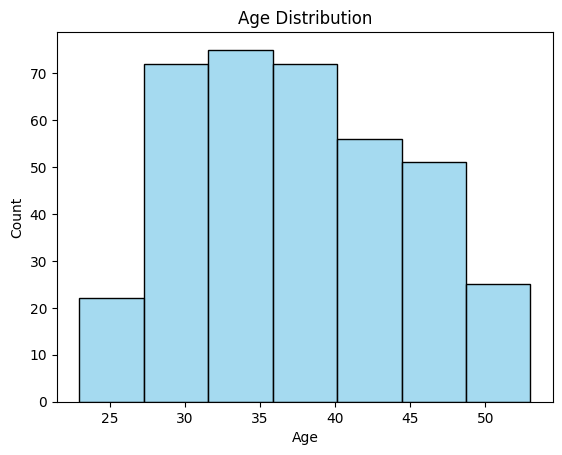

0.19752225917526042


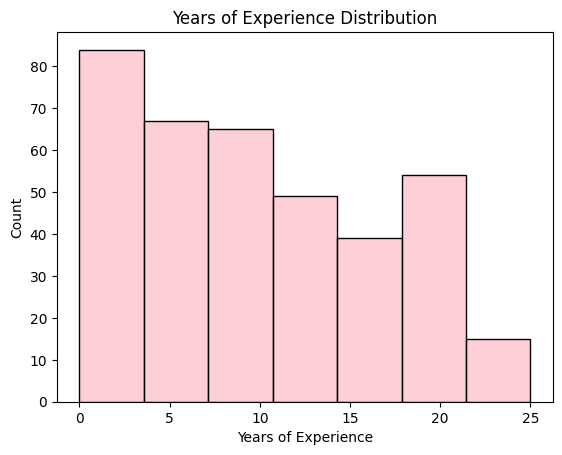

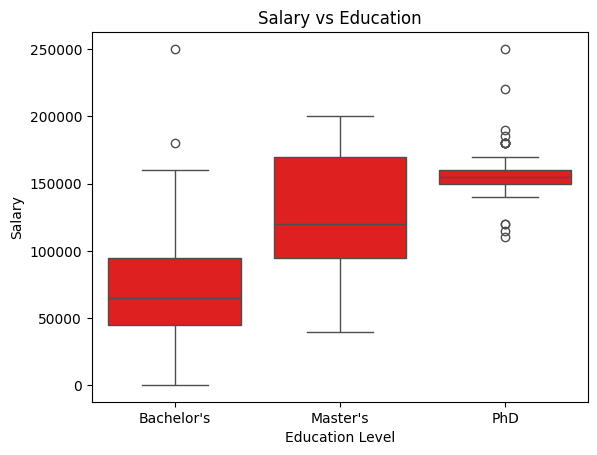

Experience Category
0-5             49367.372881
6–10 years      92578.947368
11–15 years    118230.769231
16–20 years    159140.625000
20+ years      175892.857143
Name: Salary, dtype: float64

In [5]:
#Section 3: Exploratory Data Analysis (EDA) 
plt.Figure(figsize=(8,8)) #Age Distrubution
sns.histplot(df['Age'], bins=7,color='skyblue')
plt.title('Age Distribution')
plt.show()
print(df['Age'].skew()) #Comment on Age skewness 
#Skewness > 0: Distribution is positively skewed (tail on the right).
#Skewness < 0: Distribution is negatively skewed (tail on the left).
#Skewness ≈ 0: Distribution is roughly symmetric.
plt.Figure(figsize=(8,8)) #Plot the distribution of Years of Experience. 
sns.histplot(df['Years of Experience'], bins=7,color='Pink')
plt.title('Years of Experience Distribution')
plt.show()
plt.Figure(figsize=(8,8)) # Plot a boxplot of Salary vs Education Level.
sns.boxplot(data=df,x='Education Level',y='Salary',color='Red')
plt.title("Salary vs Education")
plt.show()
df.groupby('Gender')['Salary'].mean() # Calculate the average salary by gender.
df.groupby('Education Level')['Salary'].mean() #How does education level influence the average salary?
bins=[0,5,10,15,20,float('inf')] #How do years of experience influence salary? Divide experience into 5 categories:
labels=('0-5','6–10 years', '11–15 years' ,'16–20 years' ,'20+ years ')
df['Experience Category']=pd.cut(df['Years of Experience'],bins=bins, labels=labels)
df.groupby('Experience Category')['Salary'].mean()



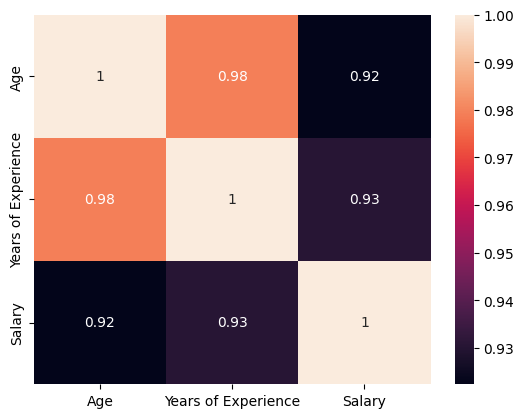

<Axes: >

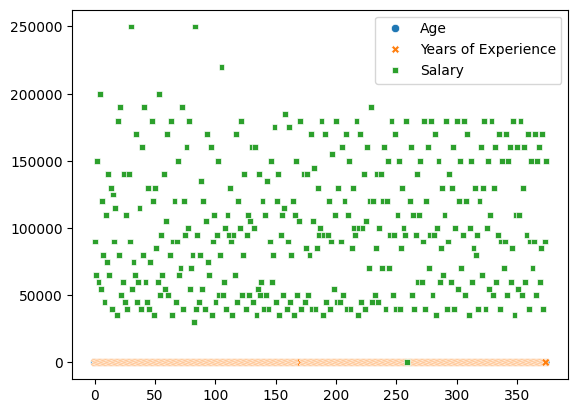

In [6]:
#Section 4: Correlation & Relationships 
plt.Figure(figsize=(10,8)) #Create a correlation heatmap of numerical columns. Which features are strongly 
#correlated with Salary? Years of experince is strongly relate to salary
num_col=df.select_dtypes(include='number')
sns.heatmap(num_col.corr(), annot=True)
plt.show()
sns.scatterplot(num_col) #Create a scatter matrix for numerical variables.Which relationships appear linear? salary

In [ ]:
#Section 5: Model Building 
X=df.drop('Salary',axis=1) #selected as features (X)? all except salary
y=df['Salary'] # target is Salary
X_train, X_test,y_test,y_train =train_test_split(X,y, test_size = 0.3, random_state = 42)
lr=LinearRegression()
lr.fit(X_train,y_train)
print('Train score', lr.score(X_train,y_train))
print('Test score', lr.score(X_test,y_test))